In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.image as mgimg
import matplotlib.colors as colors
import scipy as sp
import numpy as np
import emcee
import testkit
import corner
import pickle as pickle
from IPython.display import display
%matplotlib inline
import forwardmodel
import ciamod
import TPmod
import cloud
import band
import brewtools
from astropy.convolution import convolve, convolve_fft
from astropy.convolution import Gaussian1DKernel
from scipy import interpolate
from scipy.interpolate import interp1d
from scipy.interpolate import InterpolatedUnivariateSpline
from bensconv import prism_non_uniform
from bensconv import conv_uniform_R
from bensconv import conv_uniform_FWHM
from matplotlib.lines import Line2D

## First step is to load the results file and the run arguments. 
We open the files and select the last couple of thousand iterations of the chain, and flatted this into a simple array of state vectors called "samples"

In [93]:
path_to_results='Results/Wolf1130C/'
figure_path='Figures/Wolf1130C/'
runname = "Wolf1130C_NC"
ext_num="4"

# error for distance and photometry for corner plot R and M
sigDist = 0.007
sigPhot = 0.02 #didn't have anything this is what Ben used for 1935

# OK finish? 1 for yes, 0 for no. #also I updated brewtools because on plieades 
#I have a differen emcee version then on my laptop, or mso I though but I had to change for the next run with the .pk1 file.
fin = 1
flatendchain, flatendprobs,ndim = brewtools.get_endchain(path_to_results+runname,fin, emcee_version='3.0rc2')# need 3.0rc2 for .pk1 and 'other' for pic
print(flatendprobs)
theta_max_end = flatendchain[np.argmax(flatendprobs)]
max_end_like = np.amax(flatendprobs)
samples = flatendchain

argfile =path_to_results+runname+"_runargs.pic"

runargs = brewtools.pickle_load(argfile)
# If you're opening on a Linux box, use the code below
#with open(argfile, 'rb') as input:
#    runargs = pickle.load(input) 

gases_myP,chemeq,dist, cloudtype,do_clouds,gasnum,cloudnum,inlinetemps,coarsePress,press,inwavenum,linelist,cia,ciatemps,use_disort,fwhm,obspec,proftype,do_fudge, prof,do_bff,bff_raw,ceTgrid,metscale,coscale = runargs



maximum likelihood =  45972.26509867223
maximum likelihood in final 2K iterations=  45971.67502073233


N/50 = 600;
tau: [729.04177003 719.66997758 704.58562009 706.46419217 660.98332796
 700.08912984 723.88141386 730.59805642 673.25393759 613.38866166
 628.53543997 563.01955699 744.59562125 589.91685853 606.89302428
 634.90777498 661.09248549 661.01189998 645.97119545 654.99778881
 621.57305878 661.77786876 742.17000059 801.03683058 714.74583349
 650.87787339]


Mean autocorrelation time: 674.811 steps
[45962.77450996 45960.31755118 45958.53463247 ... 45951.86917646
 45968.61823063 45960.62219559]


Then we print the max likelihood value for the state vector, just to have a look at it

In [94]:
print(theta_max_end)

[-3.70520006e+00 -4.29649852e+00 -7.02854352e+00 -1.13215426e+01
 -5.55407607e+00 -5.34607055e+00 -7.04650190e+00  5.11199826e+00
  1.37726647e-20 -3.20368526e+01  4.31800273e+01 -3.58072533e+01
  3.15196820e+03  2.15177607e+02  3.04717263e+02  3.73351273e+02
  4.18401236e+02  4.53849643e+02  4.61291595e+02  4.26936159e+02
  4.19446114e+02  4.94932317e+02  6.93717245e+02  9.12798004e+02
  1.10772579e+03  1.29002993e+03]


And print the BIC for this run. You might want to take a note of this.

In [95]:
BIC = (-2.* max_end_like) + (ndim*np.log(obspec.shape[1]))
print("BIC = "+str(BIC))

BIC = -91731.34798803244


Next we want to plot the profile. We start by calculating the profiles from the temperature parameters in the samples array. 

This case assumes a type 1 (Line et al 2015), 13 knot profile. 

In [96]:
Tsamples = samples[:,ndim-13:]
nsamps = Tsamples.shape[0]
Tprofs = np.empty([64,Tsamples.shape[0]])
for i in range(0,nsamps):
    Tprofs[:,i] = TPmod.set_prof(1,coarsePress,press,Tsamples[i,:])

Tlays = np.empty([64,5])
for i in range(0,64):
    junk = Tprofs[i,:]
    junk2 = np.percentile(junk, [2.4,16, 50, 84,97.6],axis=0)
    junk3 = np.array(junk2)
    Tlays[i,:] = junk3[:]
    

In [97]:
# max likelihood Tprof
bestT = TPmod.set_prof(1,coarsePress,press,theta_max_end[ndim-13:])

Now we can plot it... 

In [98]:
#Load up some forward models for comparisons
sonoramodels = '/Users/eileengonzales/Dropbox/BDNYC/BDNYC_Research/Models/Marley2018_Sonoramodels/cmp/'
bobcatmodels = '/Users/eileengonzales/Dropbox/BDNYC/BDNYC_Research/Models/Sonora_Bobcat/SonoraBobcat_M-0.5_profiles/'

modP1,modT1 = np.loadtxt(sonoramodels+"t600g1000nc_m0.0.cmp",skiprows=1,usecols=(1,2),unpack=True) #solar
modP2,modT2 = np.loadtxt(bobcatmodels+"t600g1000nc_m-0.5.cmp",skiprows=1,usecols=(1,2),unpack=True) #-0.5
#modP3,modT3 = np.loadtxt("/Volumes/DudleyDisk/SONORA/Bobcat2021/Structures/t500g3160nc_m+0.5.dat",skiprows=1,usecols=(1,2),unpack=True)


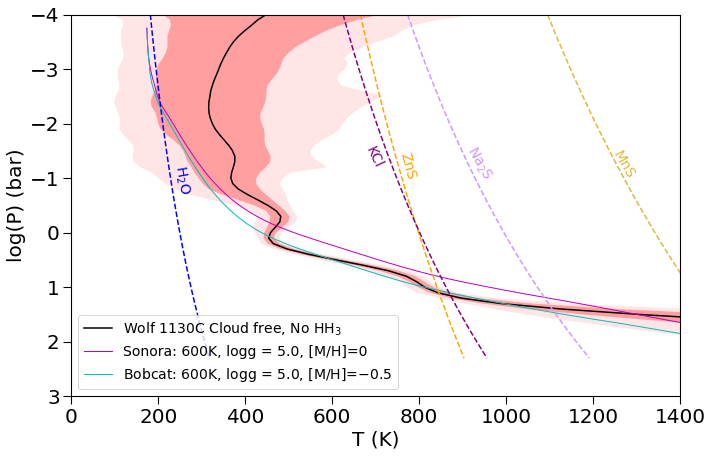

In [67]:
# plt.rc('font',family='Times New Roman')
# plt.rc('text', usetex=True)

# My usual figure configurations
fig = plt.figure()
ax1 = fig.add_subplot(111)
fig.set_size_inches(10, 6.45)
plt.gcf().subplots_adjust(bottom=0.15, left=0.15)
# plt.axis([0., 2000.,3.0,-5.0])
plt.axis([0, 1400.,3.0,-4.0])
for axis in ['top', 'bottom', 'left', 'right']:  # Thicken the frame
    ax1.spines[axis].set_linewidth(1.1)



# fig=plt.figure(dpi=320)
# plt.axis([0., 1500.,3.0,-4.0])

# ---- Plot the PT profile median and the 1 nad 2 sigma contours.-------- 
logP = np.log10(press)

d1, = plt.plot(Tlays[:,2],logP,'k-', label='Wolf 1130C Cloud free, No HH$_3$')
plt.fill_betweenx(logP,Tlays[:,1], Tlays[:,3], facecolor='red', alpha=0.3)
plt.fill_betweenx(logP,Tlays[:,0], Tlays[:,4], facecolor='red', alpha=0.1)

#------------ Plot the Maximum Likelihood ------
# l1, = plt.plot(bestT,logP,linestyle='dashdot', color='green',linewidth=1,label='max likelihood')

# -------- Plot the Model PT profiles ------------------------
m1, = plt.plot(modT1,np.log10(modP1),'m-',linewidth=1,label='Sonora: 600K, logg = 5.0, [M/H]=0')
m2, = plt.plot(modT2,np.log10(modP2),'c-',linewidth=1,label='Bobcat: 600K, logg = 5.0, [M/H]=$-$0.5')
# m3, = plt.plot(modT3,np.log10(modP3),'y-',linewidth=1,label='Bobcat 500K logg = 5.5 [M/H]=+0.3')

# ------- Plot the condensation curves -----------
# Here are some condensation curves
mns = 10.0**4/(7.45 - 0.42*logP-0.84*0.0)
na2s = 10.0**4/(10.05 - 0.72*logP-1.08*0.0)
zns = 10.0**4/(12.52 - 0.63*logP-1.26*0.0)
kcl = 10.0**4/(12.48 - 0.8786*logP-0.8786*0.0)
nh4h2po4 = 10.0**4/(29.99-0.20*(11.0*logP + 15.0*0.0))
h2o = 10000.0 / (40.042-3.730*logP - 3.730*0.0)

c1, = plt.plot(mns,logP,'--',color='#DBB93B',linewidth=1.5, label='MnS') #pick new color for this!
c2, = plt.plot(na2s,logP,'--',color='#CE96FF',linewidth=1.5,label='Na$_2$S')
c3, = plt.plot(zns,logP,'--',color='orange',linewidth=1.5, label='ZnS')
c4, = plt.plot(kcl,logP,'--',color='purple',linewidth=1.5, label='KCl')
#c5, = plt.plot(nh4h2po4,logP,'--',color='red',linewidth=1.5, label='NH$_4$H$_2$PO$_4$')
c6, = plt.plot(h2o,logP,'--',color='blue',linewidth=1.5, label='H$_2$O')

#enst = 10.0**4/(6.26 - 0.35*logP-0.70*0.0)
#fost = 10.0**4/(5.89 - 0.37*logP-0.73*0.0)
#iron = 10.0**4/(5.44 - 0.48*logP-0.48*0.0)
#cr =  10.0**4/(6.528 - 0.491*logP-0.491*0.0)
#al2o3 = 10.0**4 / (5.0139 - 0.21794*(logP) + 2.2636E-03*(logP)**2.0 - 0.580*0.0)
#c1, = plt.plot(enst,logP,'--',color='blue',linewidth=1.5, label='MgSiO$_3$')
#c2, = plt.plot(fost,logP,'--',color='pink',linewidth=1.5,label='Mg$_2$SiO$_4$')
#c3, = plt.plot(iron,logP,'--',color='orange',linewidth=1.5, label='Fe')
#c4, = plt.plot(cr,logP,'--',color='purple',linewidth=1.5, label='Cr')
#c5, = plt.plot(al2o3,logP,'--',color='red',linewidth=1.5, label='Al$_2$O$_3$')


# plt.legend(handles=[d1,l1,m1,m2,c1,c2,c3,c4,c6],bbox_to_anchor= (0.5, 1.5),loc='center', ncol=3, borderaxespad=0.2, fontsize=9)
# first_legend= ax1.legend(handles=[d1,l1,m1,m2],fontsize=14)
# ax1.add_artist(first_legend)
# plt.legend(handles=[c1,c2,c3,c4,c6],bbox_to_anchor= (0.5, 1.02),loc='center', ncol=5, borderaxespad=0.2, fontsize=12)
# plt.legend(handles=[c1,c2,c3,c4,c6],fontsize=14, loc=1)
plt.text(1240, -1, 'MnS', rotation=-60,fontsize=14, color='#DBB93B') 
plt.text(900, -1, 'Na$_2$S', rotation=-60,fontsize=14, color='#CE96FF') ##CE96FF, #CE008F
plt.text(750, -1, 'ZnS', rotation=-75,fontsize=14, color='orange') 
plt.text(670, -1.2, 'KCl', rotation=-65,fontsize=14, color='purple') 
plt.text(230, -0.75, 'H$_2$O', rotation=-80,fontsize=14, color='blue') 
plt.legend(handles=[d1,m1,m2],fontsize=14)
# plt.legend(handles=[d1,l1,m1,m2,c1,c2,c3,c4,c6],fontsize=12, loc=1)
plt.ylabel(r'log(P) (bar)', fontsize=20)
plt.xlabel('T (K)',fontsize=20)
ax1.tick_params(axis='both', labelsize=20, length=8, width=1.1)
plt.tight_layout()

#asp = 10 / 3.5

#plt.axes().set_aspect(asp)
#plt.savefig(runname+"_profile.png",format='png', dpi=320)
plt.savefig(figure_path+runname+"_ext"+ext_num+"_profile.png",format='png', dpi=320)

In [68]:
# Save the median profile as a file for plotting later.
np.savetxt(path_to_results+runname+'_profile.dat', np.c_[logP, Tlays[:,2]])
np.savetxt(path_to_results+runname+'_profile_withsig.dat', np.c_[logP, Tlays[:,1],Tlays[:,2],Tlays[:,3]])

# Next we want to plot the gas abundances in a corner plot.

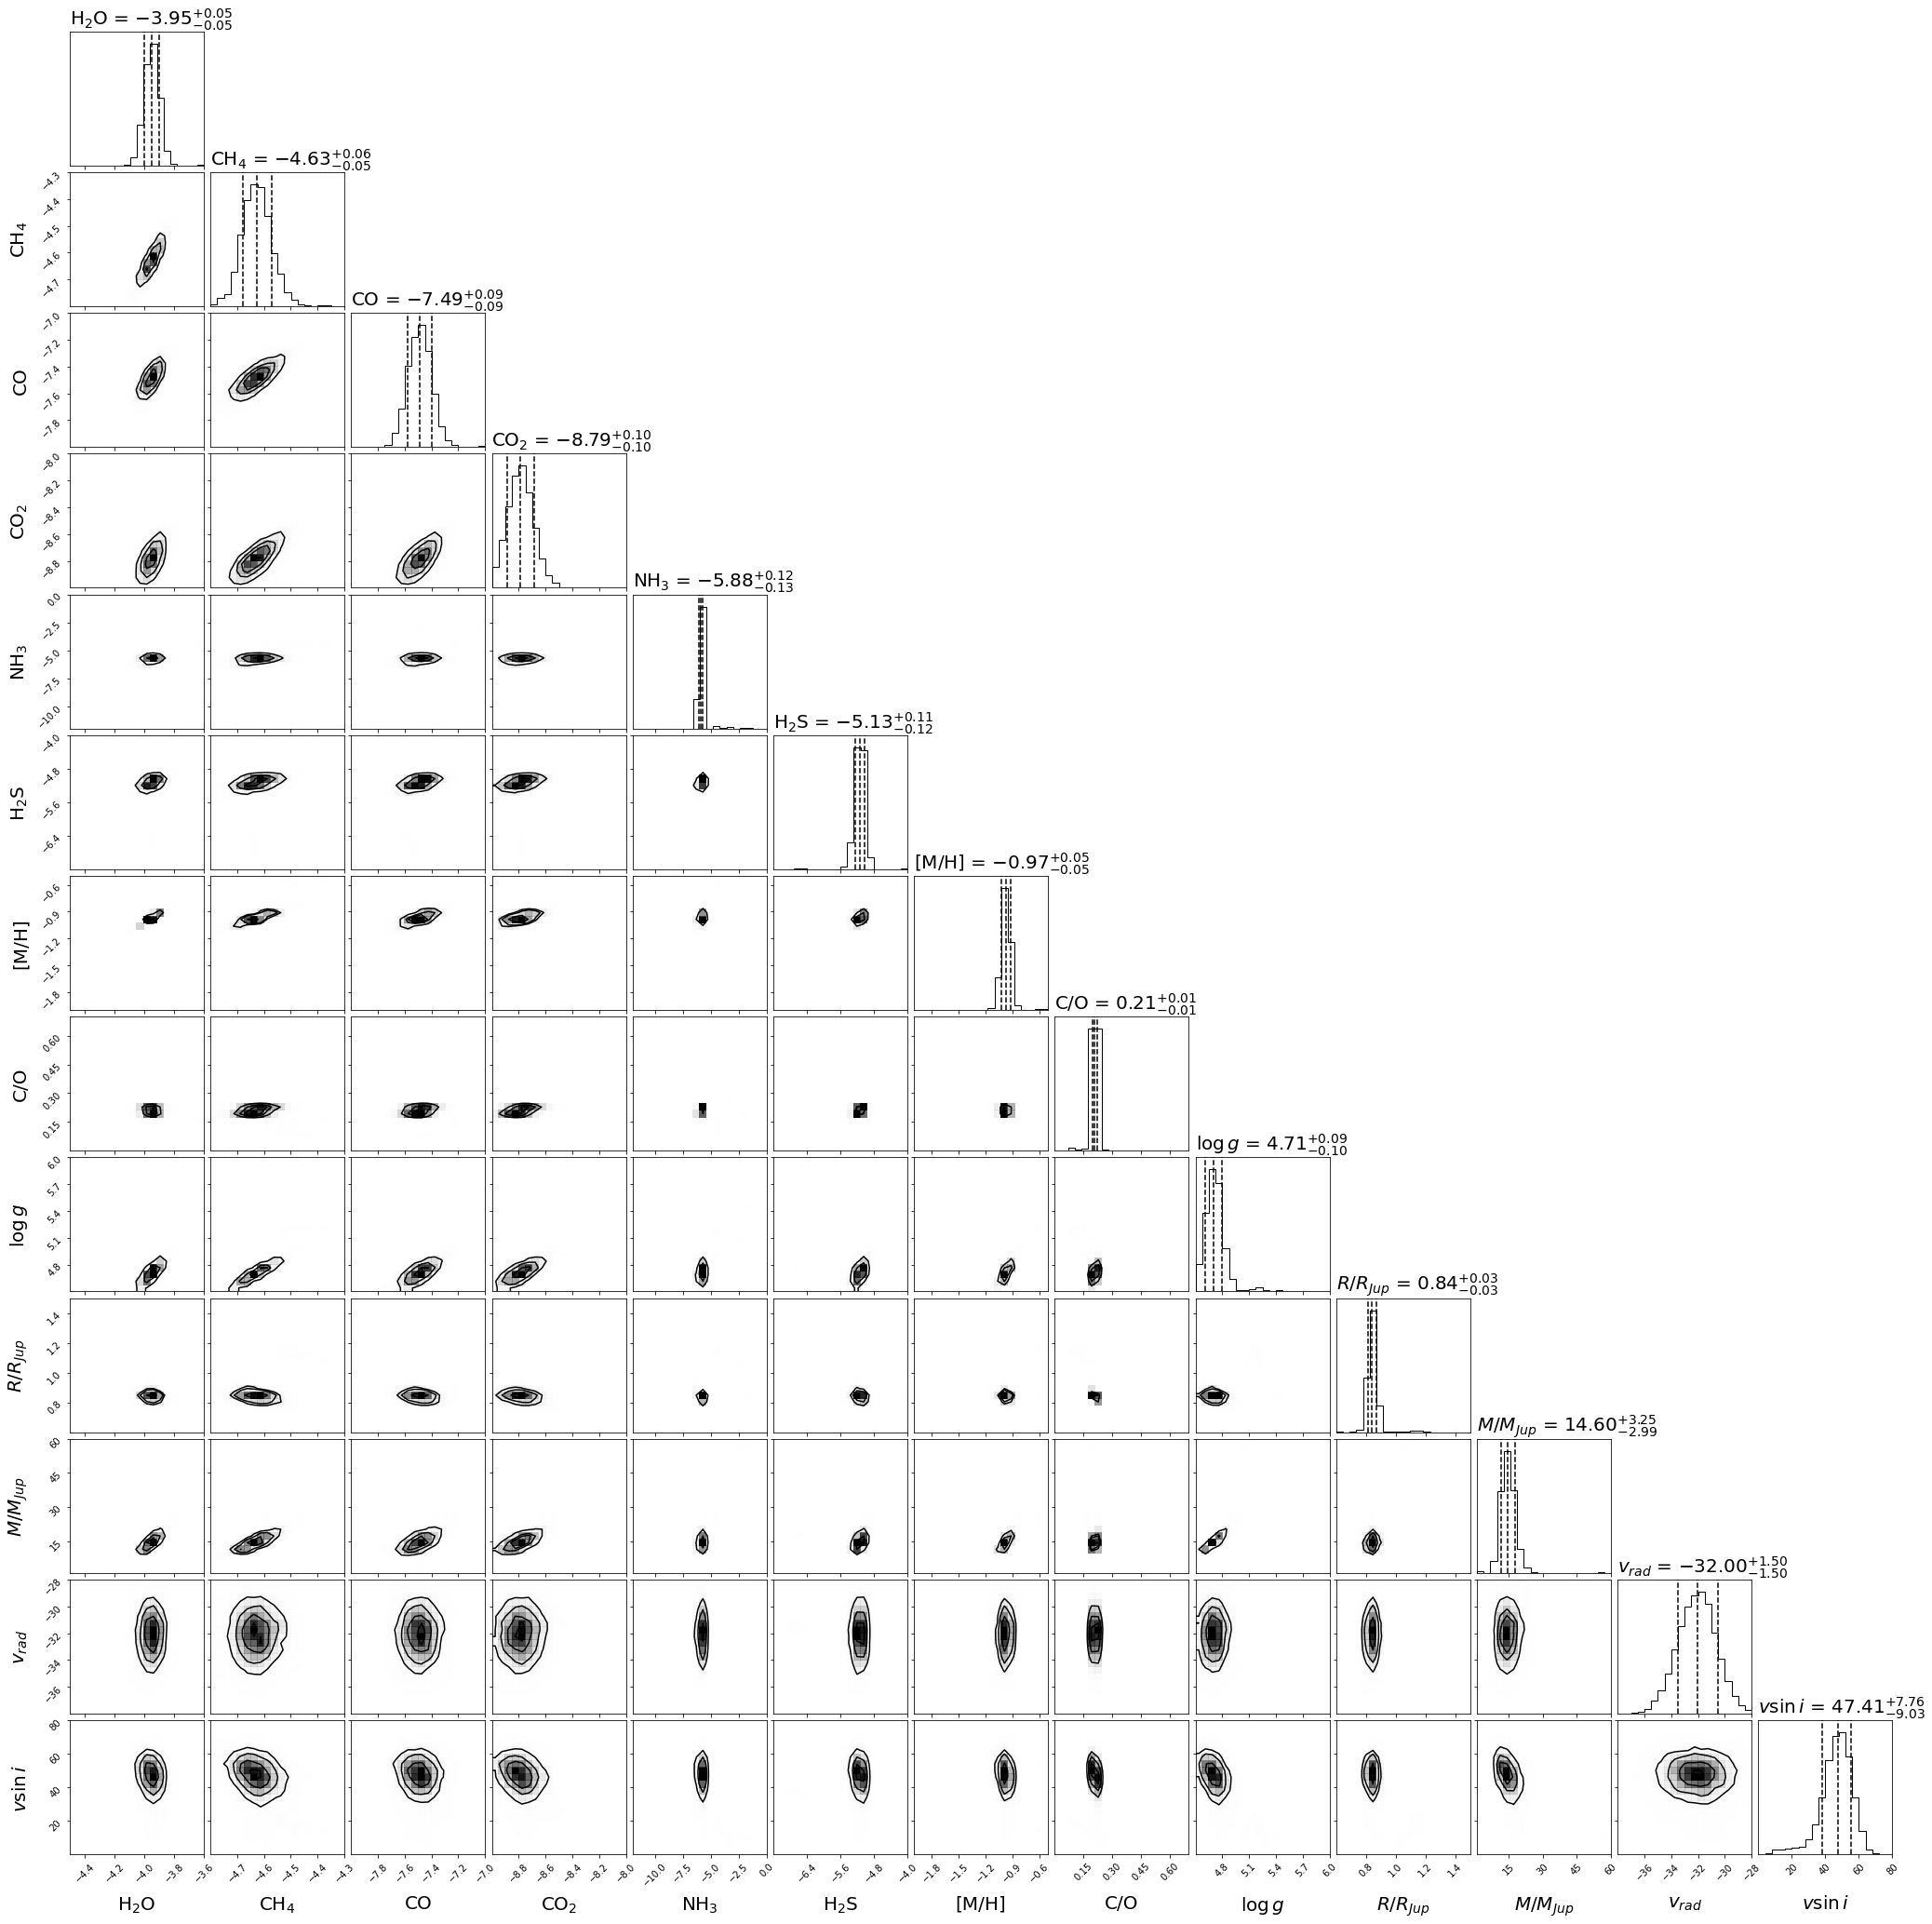

In [71]:
# You'll need to edit this cell to make it work for the gases you've used
# e.g. change the cut you take out of the samples array to get gases and gravity
gassamples = samples[:,0:13].copy()
# gassamples = samples[:,0:15].copy()
# set up boundaries for histograms
# rh2o = (-3.9,-3.55)
# rch4 = (-4.4,-4.1)
# rco = (-7.2,-6.8)
# rco2 = (-12, -8.5)
# rnh3 = (-6,-5)
# rh2s = (-6,-4)
# rph3 = (-7.2,-6.8)
# rmet = (-1,-0.5)
# rmet_full = (-1,-0.5)
# rco_rat = (0.1,0.4)
# rlogg = (4.8,5.5)
# rRad = (0.8,1)
# rMass = (15,100)
# rvrad = (-35,-30)
# rvsini = (0,80)

rh2o = (-4.5,-3.6)
rch4 = (-4.8,-4.3)
rco = (-8,-7)
rco2 = (-9, -8)
rnh3 = (-6,-5)
rh2s = (-12,0)
rph3 = (-7.2,-4)
rmet = (-2,-0.5)
rco_rat = (0,0.7)
rlogg = (4.5,6)
rRad = (0.6,1.5)
rMass = (1,60)
rvrad = (-38,-28)
rvsini = (0,80)

# get M/H and C/O
h2o = gassamples[:,0]
ch4 = gassamples[:,1]
co = gassamples[:,2]
co2 = gassamples[:,3]
nh3 = gassamples[:,4]
h2s = gassamples[:,5]
# ph3 = gassamples[:,5]

# first get the C/O

O = 10**h2o + 10**co + 2.*10**(co2) 
C = 10**(co) + 10**(co2) + 10**(ch4)

CO_ratio = C/O

# won't bother with rest of the elements as they're not fully accounted for
# i.e. N is hiding in N2, S maybe hiding elsewhere, 
# and we haven't detected PH3

#Eileen will here for Wolf1130C to compare to value.
# N = 10**nh3
S = 10**h2s
P= 10**ph3

# Determine "fraction" of H2 in the L dwarf
gas_sum = 10**h2o + 10**co +10**co2 + 10**ch4 #+10**ph3 #+ 10**h2s + 10**nh3
fH2 = (1-gas_sum)* 0.84  # fH2/(fH2+FHe) = 0.84
fH = 2.*fH2

    
# Determine linear solar abundance sum of elements in our T dwarf
# abundances taken from Asplund+ 2009
solar_H = 12.00
solar_O = 10**(8.69-solar_H)
solar_C = 10**(8.43-solar_H) 
#solar_Ti = 10**(4.95-solar_H)
#solar_V = 10**(3.93-solar_H)
#solar_Cr = 10**(5.64-solar_H)
#solar_Fe = 10**(7.50-solar_H)
#solar_NaK = 10**(6.24-solar_H) + 10**(5.03-solar_H)
solar_N = 10**(7.83-solar_H)
solar_S = 10**(7.12-solar_H)
solar_P = 10**(5.41-solar_H)
    
# Calculate the metallicity fraction in the star and the same for the sun and then make the ratio
#Eileen will include Ph3 as it is constrained!
metallicity_target = (O/fH) + (C/fH) #+ (P/fH)
metallicity_sun = solar_O + solar_C #+ solar_P

MH = np.log10(metallicity_target / metallicity_sun)

# # Calculate the metallicity fraction in the star and the same for the sun using all retrieved metals and then make the ratio
# metallicity_target_full = (O/fH) + (C/fH) + (P/fH)+ (N/fH)+ (S/fH)
# metallicity_sun_full = solar_O + solar_C + solar_P+solar_N +solar_S 

# MH_full = np.log10(metallicity_target_full / metallicity_sun_full)

# Get the radius and mass
r2d2 = samples[:,7].copy()
logg = samples[:,6].copy()
# r2d2 = samples[:,8].copy()
# logg = samples[:,7].copy()
# Radius
sigR2D2 = sigPhot * r2d2 * (-1./2.5)* np.log(10.)

sigD = sigDist * 3.086e16
D = dist * 3.086e16

R = np.sqrt(((np.random.randn(len(samples[:,0])) * sigR2D2)+ r2d2)) * ((np.random.randn(len(samples[:,0]))* sigD) + D)


# and mass
g = (10.**logg)/100.
M = (R**2 * g/(6.67E-11))/1.898E27
 
R = R / 71492e3

gassamples[:,6] = MH
gassamples[:,7] = CO_ratio
gassamples[:,8] = logg
gassamples[:,9] = R
gassamples[:,10] = M
gassamples[:,11:13] = samples[:,8:10].copy()

# gassamples[:,7] = MH
# gassamples[:,8] = CO_ratio
# gassamples[:,9] = logg
# gassamples[:,10] = R
# gassamples[:,11] = M
# gassamples[:,12:14] = samples[:,9:11].copy()
# gassamples[:,14] = MH_full
# now make an array of the bounds to give to corner plot
# bnds = [rh2o,rch4,rco,rco2,rnh3,rh2s,rph3,rmet,rco_rat,rlogg,rRad,rMass,rvrad,rvsini,rmet_full]
# # range = bnds,

# fig = corner.corner(gassamples,scale_hist=False, plot_datapoints =False,range = bnds,
#                     labels=["H$_2$O","CH$_4$","CO","CO$_2$","NH$_3$","H$_2$S","PH$_3$","[M/H]","C/O","$\log g$",
#                             "$R / R_{Jup}$","$M / M_{Jup}$","$v_{rad}$","$v \sin i$","[M/H]_full"],quantiles=[0.16, 0.5, 0.84],
#                     show_titles=True, title_kwargs={"fontsize": 20,"loc":"left"},label_kwargs={"fontsize": 20})
# #plt.savefig(runname+"_MRgascorner.png",bbox_inches='tight',format='png', dpi=320)
# plt.savefig(figure_path+runname+"_ext"+ext_num+"_gascorner_full.png",format='png', dpi=320)



bnds = [rh2o,rch4,rco,rco2,rh2s,rph3,rmet,rco_rat,rlogg,rRad,rMass,rvrad,rvsini]
fig = corner.corner(gassamples,scale_hist=False, plot_datapoints =False,range = bnds,
                    labels=["H$_2$O","CH$_4$","CO","CO$_2$","NH$_3$","H$_2$S","[M/H]","C/O","$\log g$",
                            "$R / R_{Jup}$","$M / M_{Jup}$","$v_{rad}$","$v \sin i$"],quantiles=[0.16, 0.5, 0.84],
                    show_titles=True, title_kwargs={"fontsize": 20,"loc":"left"},label_kwargs={"fontsize": 20})
#plt.savefig(runname+"_MRgascorner.png",bbox_inches='tight',format='png', dpi=320)
plt.savefig(figure_path+runname+"_ext"+ext_num+"_gascorner_full.png",format='png', dpi=320)

In [72]:
# This saves out the gas mixing ratios
gasVMR = np.ones([gasnum.size,3])
for i in range (0,gasnum.size):
    gasVMR[i,:] = np.percentile(samples[:,i], [16, 50, 84])
    
# np.savetxt(runname+'_VMRs.dat', np.c_[gasVMR[:,0],gasVMR[:,1],gasVMR[:,2]])
np.savetxt(path_to_results+runname+'_VMRs.dat', np.c_[gasVMR[:,0],gasVMR[:,1],gasVMR[:,2]])


# Plotting the model spectra
To plot the model spectra we need to rerun the model, and rerun it for a bunch of random draws from the posterior. This will allow us to plot either a spaghetti plot, or a median + interval spectrum

In [99]:
# no need to get diagnostics along with the spectrum
gnostics = 0
# Now run the model again to get your model spectrum and process to make it look like the data
shiftspec, photspec, tauspec,cfunc = testkit.modelspec(theta_max_end,runargs,gnostics)
topspec = brewtools.proc_spec(shiftspec,theta_max_end,fwhm,chemeq,gasnum,obspec) 


In [100]:
print(topspec)

[4.45558227e-18 3.84787217e-18 4.74592591e-18 ... 2.42196973e-18
 2.30482443e-18 2.27101969e-18]


In [101]:
print(theta_max_end)

[-3.70520006e+00 -4.29649852e+00 -7.02854352e+00 -1.13215426e+01
 -5.55407607e+00 -5.34607055e+00 -7.04650190e+00  5.11199826e+00
  1.37726647e-20 -3.20368526e+01  4.31800273e+01 -3.58072533e+01
  3.15196820e+03  2.15177607e+02  3.04717263e+02  3.73351273e+02
  4.18401236e+02  4.53849643e+02  4.61291595e+02  4.26936159e+02
  4.19446114e+02  4.94932317e+02  6.93717245e+02  9.12798004e+02
  1.10772579e+03  1.29002993e+03]


In [102]:
# Now grab 500 random draws from the posterior
pltspec = np.zeros((100,obspec[0,:].size))
samp= np.empty(ndim)
sid = np.zeros(100)
for i in range (0,100):
    sid[i]= np.random.randint(0,high = len(samples))
    samp = samples[int(sid[i]),:]
    shiftspec, photspec, tauspec,cfunc = testkit.modelspec(samp,runargs,gnostics)
    pltspec[i,:] = brewtools.proc_spec(shiftspec,samp,fwhm,chemeq,gasnum,obspec) 
    
# get the intervals for the distribution of model spectra
specdist = np.empty([obspec[0].size,5])
for i in range(0,obspec[0].size):
    junk = pltspec[:,i]
    junk2 = np.percentile(junk[~np.isnan(junk)], [2.4,16, 50, 84,97.6])
    junk3 = np.array(junk2)
    specdist[i,:] = junk3[:]

KeyboardInterrupt: 

# plot the spectra

In [ ]:
# plt.rc('font',family='Times New Roman')
# plt.rc('text', usetex=True)
fig=plt.figure(dpi=320)
# fig.set_size_inches(10, 15)
fig, axs = plt.subplots(6,gridspec_kw={'hspace': 1, 'wspace': 1}) #,'height_ratios': [1,1,1,1,1,2]
# asp = 10.0

for i in range(0,6):
    lsize = 8

    axs[i].set(xlim=[2.8+(i*0.4),3.2+(i*0.4)])
    # set the plot range for each plot
    xr =  np.where(np.logical_and(obspec[0,:] > (2.8+(i*0.4)),obspec[0,:] < 3.2+(i*0.4)))
    xr = xr[0]
    
    d1, = axs[i].plot(obspec[0,xr],obspec[1,xr]/1e-17,'k-',label = runname+" data")
    axs[i].fill_between(obspec[0,xr],(obspec[1,xr]-obspec[2,xr])/1e-17,(obspec[1,xr]+obspec[2,xr])/1e-17,facecolor='gray',alpha=0.5)
    r1, = axs[i].plot(obspec[0,xr],specdist[xr,2]/1e-17,'y-',linewidth=0.8, label = "median", zorder=5)
    plt.fill_between(obspec[0],specdist[:,0],specdist[:,4],facecolor='red',alpha=0.2)
    axs[i].fill_between(obspec[0,xr],specdist[xr,1]/1e-17,specdist[xr,3]/1e-17,facecolor='red',alpha=0.5)

    t1, = axs[i].plot(obspec[0,xr],topspec[xr]/1e-17,'g-',linewidth=0.5, label = "max likelihood", zorder=4)
    
    if i == 0:
#         axs[i].legend(handles=[d1,r1,t1],bbox_to_anchor=(1.05,1.2),loc='upper left')
        axs[i].legend(handles=[d1,r1,t1],bbox_to_anchor= (0.5, 1.5),loc='center', ncol=3, borderaxespad=0.2, fontsize=9)
    
    
#plt.ylabel(r'$ F_{\lambda}$ / $10^{-17} Wm^{-2} \mu m^{-1}$',loc='center')
#plt.xlabel('Wavelength / $\mu m$')


# fig.txt = fig.text(0.5, 0.04,'Wavelength ($\mu m$)', ha='center')
# fig.text(0.05, 0.5,r'$ F_{\lambda}$ ($10^{-17}~{\rm Wm^{-2} \mu m^{-1}}$)' , va='center', rotation='vertical')

plt.ylabel(r'                                       $ F_{\lambda}$ ($10^{-17}~{\rm Wm^{-2} \mu m^{-1}}$)', fontsize=15)
plt.xlabel('Wavelength ($\mu m$)',fontsize=15)
#plt.savefig(runname+"_panel_spec.png",format='png', dpi=320)
# plt.savefig(figure_path+runname+"_ext"+ext_num+"_SPAG_SPEC.png",format='png', dpi=320)
# plt.savefig(figure_path+runname+"_Pub_SPAG_SPEC.pdf",format='pdf', dpi=320)

In [92]:
print(obspec[0,xr])

[4.8005543 4.8012142 4.8018737 4.8025327 4.8031926 4.8038526 4.8045125
 4.805172  4.8058314 4.8064914 4.8071513 4.8078103 4.8084698 4.8091297
 4.8097892 4.8104482 4.8111081 4.8117676 4.812427  4.813087  4.8137469
 4.8144059 4.8150654 4.8157248 4.8163838 4.8170438 4.8177032 4.8183627
 4.8190217 4.8196812 4.8203406 4.8209996 4.8216596 4.822319  4.8229785
 4.8236375 4.824297  4.8249564 4.8256154 4.8262749 4.8269343 4.8275933
 4.8282528 4.8289123 4.8295712 4.8302307 4.8308902 4.8315158 4.8321748
 4.8328342 4.8334928 4.8341527 4.8348117 4.8354707 4.8361301 4.8367887
 4.8374481 4.8381076 4.8387666 4.8394256 4.8400846 4.840744  4.8414035
 4.842062  4.8427205 4.84338   4.8440394 4.8446651 4.8453236 4.8459821
 4.8466415 4.847301  4.8479595 4.848618  4.8492775 4.849937  4.8505955
 4.851254  4.8519135 4.852572  4.853231  4.8538899 4.8545489 4.8552079
 4.855866  4.8565254 4.8571849 4.8578429 4.8585019 4.8591609 4.8598194
 4.8604779 4.8611369 4.8617959 4.8624539 4.8631134 4.8637719 4.86443
 4.86508

In [91]:
print(specdist[:,2])
print(obspec[1,:]-specdist[:,2])

[4.41483279e-18 3.84869630e-18 4.80415345e-18 ... 2.59826065e-18
 2.53097703e-18 2.55102964e-18]
[-8.77452067e-19 -6.17760901e-19 -2.32153585e-18 ...  2.09321237e-19
 -3.55836715e-19 -1.98468205e-18]


In [80]:
stat= np.sum(((obspec[1,:] - topspec)**2) / (obspec[2,:]**2 + 10**theta_max_end[ndim-15]))
    # And divide it by the number of data points to get reduced chi^2
chi2 = stat / len(obspec[0])
print('with tolerance parameter chi2 = ',chi2)
stat= np.sum(((obspec[1,:] - topspec)**2) / (obspec[2,:]**2))
    # And divide it by the number of data points to get reduced chi^2
chi2 = stat / len(obspec[0])

print('without tolerance parameter chi2 = ',chi2)

with tolerance parameter chi2 =  1.0839225581917717
without tolerance parameter chi2 =  28.38251435715224


In [ ]:
# Save you  model spectra
# np.savetxt(path_to_results+runname+'_MEDIAN_SPEC.dat', np.c_[obspec[0,:],specdist[:,2],specdist[:,1],specdist[:,3]])
# np.savetxt(path_to_results+runname+'_MAX_LIKE_SPEC.dat', np.c_[obspec[0,:],topspec])
np.savetxt(path_to_results+runname+'_observed_SPEC.dat', np.c_[obspec[0,:],obspec[1,:]])

# Contribution function
Finally, the contribution function. This is a really useful plot...

In [ ]:
# get diagnostics along with the spectrum
gnostics = 1
shiftspec, clphotspec, ophotspec,cfunc = testkit.modelspec(theta_max_end,runargs,gnostics)

nwave = inwavenum.size
cfunc = np.reshape(cfunc,[cfunc.shape[1],cfunc.shape[2]])
fwhm = 4/3000
wlen = shiftspec.shape[1]
wint =  shiftspec[0,0] - shiftspec[0,wlen-1]
# convolve with instrumental profile
# start by setting up kernel
# First step is finding the array index length of the FWHM
disp = wint / wlen
gwidth = int((((fwhm / disp) // 2) * 2) +1)
# needs to be odd
# now get the kernel and convolve
gauss = Gaussian1DKernel(gwidth)

for ilayer in range (0,press.size):
    cfunc[:,ilayer] = convolve(cfunc[:,ilayer],gauss,boundary='extend')

tau1_cl_Press = convolve(clphotspec[0],gauss,boundary='extend')[::-1]
tau1_oth_Press = convolve(ophotspec[0],gauss,boundary='extend')[::-1]
    
wavenew = shiftspec[0,::-1]
press = press.reshape(64,)
normfunc = np.zeros_like(cfunc)
for iwave in range(0,nwave):
    totcont = np.sum(cfunc[iwave,:])
    normfunc[iwave,:] = cfunc[iwave,:] / totcont

    
# plt.rc('font', family='serif')
# plt.rc('text', usetex=False)
#fig=plt.figure(dpi=120)

fig, ax = plt.subplots()
ax.axis([wavenew[0],wavenew[-1],press[-1],press[0]])

ax.set_yscale('log')
ax.set_xscale('log')
#major_ticks = np.arange(1.0,15.,1.0)
#minor_ticks = np.arange(1.0,15.,0.5)
#ax.set_xticks(major_ticks)                                                       
#ax.set_xticks(minor_ticks, minor=True)                                           

cm = ax.pcolormesh(wavenew,press,(normfunc[::-1,:].transpose()),
                   cmap='Greys',norm=colors.SymLogNorm(linthresh=0.001,linscale=0.00001,
                                                       vmin=0., vmax=np.amax(normfunc)))

#t1, = plt.plot(wavenew,(tau1_cl_Press),'m-',label=r'$\tau_{cloud} = 1.0$')
t2, = ax.plot(wavenew,(tau1_oth_Press),'c-', label =r'$\tau_{gas} = 1.0$')

#fig.legend(handles=[t2])

cbar = fig.colorbar(cm,ax=ax,orientation='vertical',norm=colors.Normalize(clip=False),ticks=[1e-3,1e-2,0.1])
cbar.ax.set_yticklabels(['<0.1%', '1%', '10%'])
cbar.set_label('% of total', rotation=270, fontsize=20)
plt.ylabel('Pressure (bar)', fontsize=20)
plt.xlabel('Wavelength ($\mu m$)', fontsize=20)
plt.savefig(figure_path+runname+"_ext"+ext_num+'_contribution.png',format='png', dpi=120)

['h2o', 'ch4', 'co', 'co2', 'h2s', 'ph3']


<Figure size 3200x3840 with 0 Axes>

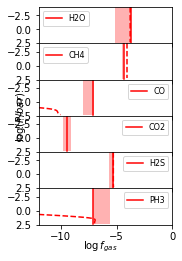

In [59]:
# grab BFF and Chemical grids
gaslist = ['h2o','ch4','co','co2','h2s','ph3'] #,'nh3'
print(gaslist)
chemeq=1
bff_raw,ceTgrid,metscale,coscale,gases_myP = testkit.sort_bff_and_CE(chemeq,"chem_eq_tables_P3K.pic",press,gaslist)

#This grid looks crazy when plotting at low t ask CHannon about it.
#bff_raw,ceTgrid,metscale,coscale,gases_myP = testkit.sort_bff_and_CE(chemeq,"chem_eq_tables_grid_500_6000_P3K.pic",press,gaslist)

# what metallicity and C/O ratio do we want to plot?
mh  = -0.7
co = (0.45/0.45)

logP, profT = np.loadtxt(path_to_results+runname+"_profile.dat",unpack=True)

nlayers = press.size
mfit = interp1d(metscale,gases_myP,axis=0)
gases_myM = mfit(mh)
cfit = interp1d(coscale,gases_myM,axis=0)
invmr = cfit(co)
ng = invmr.shape[2]
ngas = len(gaslist)
ab = np.zeros([nlayers,ngas],dtype='d')
temp= profT #Tlays[:,2]
for p in range(0,nlayers):
    for g in range(3,ng):
        tfit = InterpolatedUnivariateSpline(ceTgrid,invmr[:,p,g])
        ab[p,g-3]= tfit(temp[p])

vmr = gasVMR

# plt.rc('font',family='Helvetica')
# plt.rc('text', usetex=True)
fig=plt.figure(dpi=320)
fig.set_size_inches(10., 12.)
fig, axs = plt.subplots(ngas,sharex='col', sharey='row',gridspec_kw={'hspace': 0, 'wspace': 0})


asp = 0.5

for i in range(0,ngas):
    lsize = 8
    # row and column sharing

    axs[i].set(xlim=[-12, 0], ylim=[2.5,-4], aspect=asp)
    axs[i].plot(ab[:,i],logP,'--',color='red',linewidth=1.5)
    c1, = axs[i].plot([vmr[i,1],vmr[i,1]],[2.4,-4.0],'-',color='red',label=gaslist[i].upper())
    axs[i].fill_betweenx([2.4,-4.0],[vmr[i,0],vmr[i,0]],[vmr[i,2],vmr[i,2]], facecolor='red', alpha=0.3,linewidth=0)
    axs[i].legend(handles=[c1],prop={'size':lsize})

# this bit is Na+K tied together. If they're not, remove this bit, and run the loop above to ngas
#alks = np.log10((10.**ab[:,ngas-2]) + (10.**ab[:,ngas-1]))

#axs[ngas-2].set(xlim=[-12, 0], ylim=[2.5,-4], aspect=asp)  
#axs[ngas-2].tick_params(axis='y',direction='in',left=True,right=True)
#axs[ngas-2].plot(alks,logP,'--',color='red',linewidth=2)
#c7, = axs[ngas-2].plot([vmr[ngas-2,1],vmr[ngas-2,1]],[2.4,-4.0],'-',color='red',label='Na+K')
#axs[ngas-2].fill_betweenx([2.4,-4.0],[vmr[ngas-2,0],vmr[ngas-2,0]],[vmr[ngas-2,2],vmr[ngas-2,2]], facecolor='red', alpha=0.1,linewidth=0)
#axs[ngas-2].legend(handles=[c7],prop={'size':lsize})



fig.txt = fig.text(0.5, 0.04, '$\log f_{gas}$', ha='center')
fig.text(0.3, 0.5, '$\log (P / bar)$', va='center', rotation='vertical')
plt.savefig(figure_path+runname+"_ext"+ext_num+'_abundances.png',format='png', dpi=320)

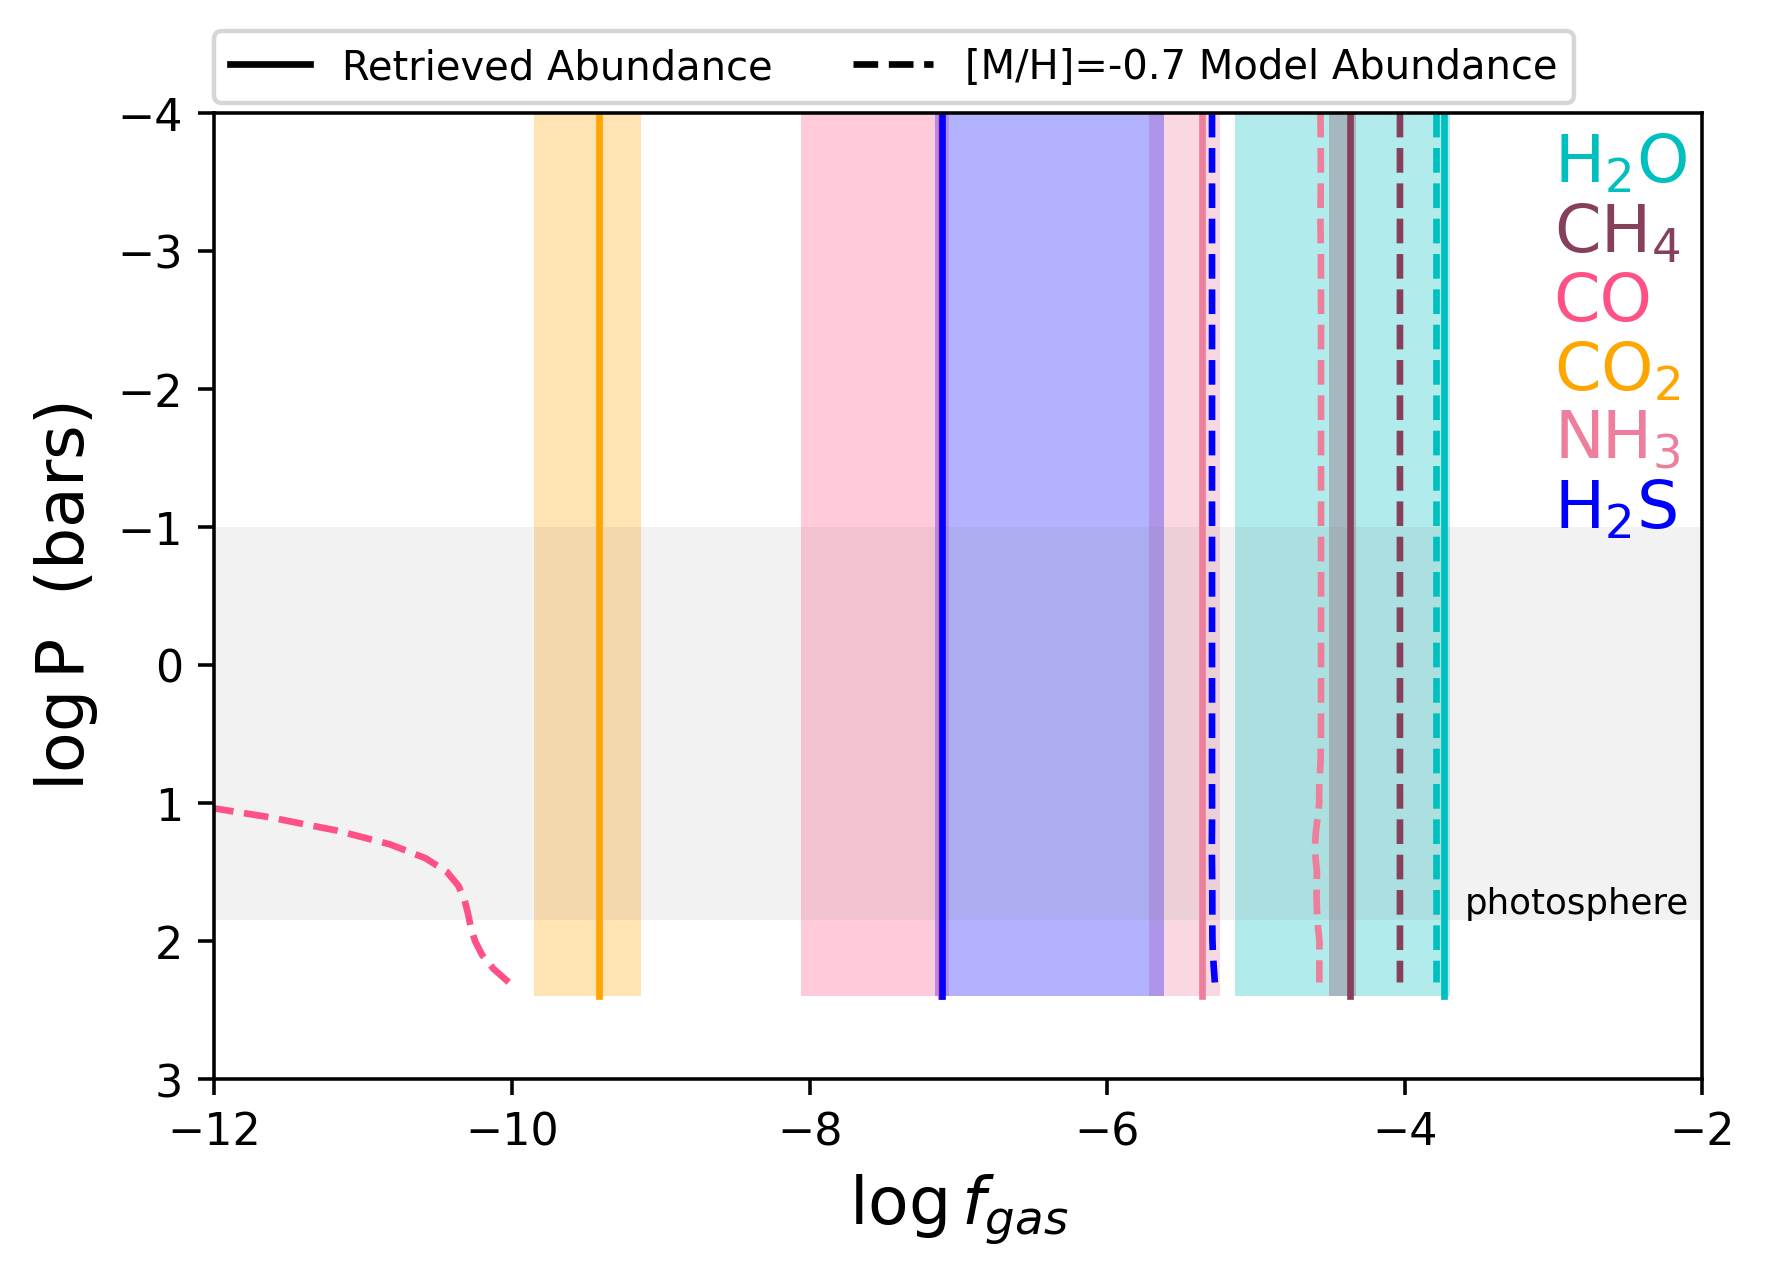

In [58]:
#plot them all together instead
# plt.rc('font',family='Helvetica')
# plt.rc('text', usetex=True)
fig6=plt.figure(dpi=320)
# ax = fig.add_subplot(1,1,1)
plt.axis([-12, -2, 3.0, -4.0])

colors=['#00BFBF','#87405C','#FF5186', 'orange', '#EE7F9C', 'blue','#678D56']
# gas_names_list =['h2o', 'ch4', 'co', 'co2', 'nh3', 'h2s', 'ph3']
gas_names_list =['H$_{2}$O', 'CH$_{4}$', 'CO', 'CO$_{2}$', 
                 'NH$_{3}$', 'H$_{2}$S']#, 'PH$_{3}$']


for i, (color, gas_names_list) in enumerate (zip(colors, gas_names_list)):
    plt.plot(ab[:,i],logP,'--',color=color,linewidth=1.5)
    plt.plot([vmr[i,1],vmr[i,1]],[2.4,-4.0],'-',color=color,label=gas_names_list.upper())
    plt.fill_betweenx([2.4,-4.0],[vmr[i,0],vmr[i,0]],[vmr[i,2],vmr[i,2]], facecolor=color, alpha=0.3,linewidth=0)

plt.fill_between([-12.0,12.0],np.log10(70),np.log10(0.1),facecolor='grey',alpha=0.1) # block for the photosphere
plt.annotate('photosphere', xy=(-3.6, 1.8), color='k', fontsize=8)  
# plt.annotate('- - [M/H]=-0.5', xy=(-3.45, -0.2), color='k', fontsize=10)  
# plt.annotate('Model', xy=(-3.3, 0.2), color='k', fontsize=10)  

# Get automatic labels
handles, labels =plt.gca().get_legend_handles_labels()

#Create my Own label and append to the legend
# line = Line2D([0], [0], linestyle='--', label='[M/H]=-0.7 \n Model', color='k')
# handles.extend([line])
# plt.legend(handles=handles, loc='upper right',fontsize=8)  


# Add legend and labels that are shared over all the subplots
# create lines for custom legend
custom_lines = [Line2D([0], [0], color='k', ls='-'),
                Line2D([0], [0], color='k', ls='dashed')]
legend=plt.legend(custom_lines, ['Retrieved Abundance', '[M/H]=-0.7 Model Abundance'], loc='lower left',
                  bbox_to_anchor= (0, 1.01), ncol=2, borderaxespad=0, fontsize=9)


plt.annotate('H$_\mathrm{2}$O', xy=(-3, -3.5), color='#00BFBF', fontsize=15) 
plt.annotate('CH$_\mathrm{4}$', xy=(-3, -3), color='#87405C', fontsize=15)
plt.annotate('CO', xy=(-3, -2.5), color='#FF5186', fontsize=15)
plt.annotate('CO$_\mathrm{2}$', xy=(-3, -2), color='orange', fontsize=15)
plt.annotate('NH$_\mathrm{3}$', xy=(-3, -1.5), color='#EE7F9C', fontsize=15)
plt.annotate('H$_\mathrm{2}$S', xy=(-3, -1), color='blue', fontsize=15)
#plt.annotate('PH$_\mathrm{3}$', xy=(-3, -0.5), color='#678D56', fontsize=15)


#Add axes Labels
plt.ylabel('log$\,$P  (bars)',fontsize=15)
plt.xlabel('log$\,f_{gas}$',fontsize=15)
plt.savefig(figure_path + runname +"_ext"+ext_num+ '_abundances_new1.pdf', format='pdf', dpi=320, bbox_inches='tight')

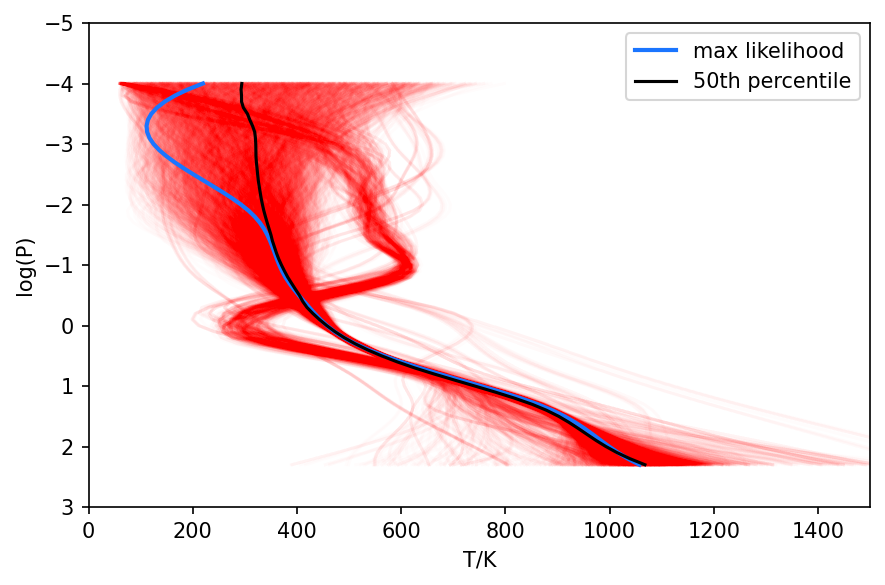

In [56]:
# ------------------------------- Plot that spag! -----------------------------------------------------------------
# plt.rc('font',family='Times New Roman')
fig = plt.figure(dpi=150)
plt.axis([0., 1500., 3.0, -5.0])
#plt.plot(outspec[0,:],(outspec[1,:] / B),'r-')
#plt.plot(outspec[0,:],B,'b-')
#plt.fill_between(T[:,1],T[:,2], logP,facecolor='red',interpolate=True)
#plt.plot(T[:,1],logP,'r--')
#plt.plot(T[:,2],logP,'r--')
samp = np.empty(ndim)
sampT = np.empty(13) # this needs to be modified based on profile type

for samp[:] in flatendchain[(np.random.randint(len(flatendchain[:,:]), size=5000)),:]:
    sampT[:] = samp[ndim-13:] # change for number of parameters 13 for prof 1, 5 or 6 for profs 2 and 3
    plotT =TPmod.set_prof(1, coarsePress,press,sampT[:])  # check your prof type value!
    plt.plot(plotT,logP, color="r", alpha=0.01)


bestT = TPmod.set_prof(1, coarsePress,press,theta_max_end[ndim-13:])  # check your prof type value!
maxlike, = plt.plot(bestT,logP,"#1A75FF", linewidth=2, label="max likelihood")
d1, = plt.plot(Tlays[:,2],logP,'k-',label='50th percentile')


plt.ylabel(r'log(P)')
plt.xlabel('T/K')
plt.legend(handles=[maxlike, d1])
plt.tight_layout()
plt.savefig(figure_path+runname+"_ext"+ext_num+'_SPAG.png',format='png', dpi=320)

In [30]:
# New upper plot in color does this.

# Plot Up the VMR abundances
# -- Read in the CE table that you want to compare your retrieved gas abundances to --
# intab = np.loadtxt("2015_07_1224grid_feh_00_co_10.txt", skiprows=1) # Solar Fe/H and C/O grid.
# intab = np.loadtxt("2015_06_1060grid_feh_00_co_10.txt", skiprows=1)
intab = np.loadtxt("201507_grid500_fehm050_co_100.txt", skiprows=1) # Fe/H=-0.5 and Solar C/O grid.
# intab = np.loadtxt("2015_07_1224grid_fehm50_co_10.txt", skiprows=1)

# Reshape the array and make a pressure and temp array. #Needs to be modified to use the newer grid
# test = np.array(intab)
# test2 = test.reshape(60, 18, 36)
# Pgrid = test2[20:21, :, 1]
# Pgrid = Pgrid.reshape(18)
# Tgrid = test2[:, 10:11, 0].reshape(60)
# abunds = test2[:, :, 2:]


# Reshape the array and make a pressure and temp array modified to use the newer grid
test = np.array(intab)
test2 = test.reshape(68, 18, 40)
Pgrid = test2[20:21, :, 1]
Pgrid = Pgrid.reshape(18)
Tgrid = test2[:, 10:11, 0].reshape(68)
abunds = test2[:, :, 2:]

#---- Read in your profile and setup a pressure grid to match the table ------
logP, profT = np.loadtxt(path_to_results+runname + "_profile.dat", unpack=True) #sizes: 64,64
# logP, profT = np.loadtxt(path_to_results+"G570D_newalkalies_profile.dat", unpack=True)
nlayers = logP.size
npress = 18
ntemp = 68 #60 for old
ngas = 38 #34 for old  # two less than the number of gases in the grid b/c grid has gases + Temp + Pressure
ab_myP = np.empty([ntemp, nlayers, ngas])

# Loop over the number of gases, interpolate the Pgrid, and output to the pressure grid of the retrieval.
for gas in range(0, ngas):
    for i in range(0, ntemp):
        pfit = interp1d(Pgrid, np.log10(abunds[i, :, gas]))
        ab_myP[i, :, gas] = pfit(logP)

# Now get the abundances for this profile....
ab = np.empty([nlayers, ngas])
for gas in range(0, ngas):
    for i in range(0, nlayers):
        tfit = InterpolatedUnivariateSpline(Tgrid, ab_myP[:, i, gas], k=1)
        ab[i, gas] = tfit(profT[i])
vmr = gasVMR

IndexError: index 6 is out of bounds for axis 0 with size 6

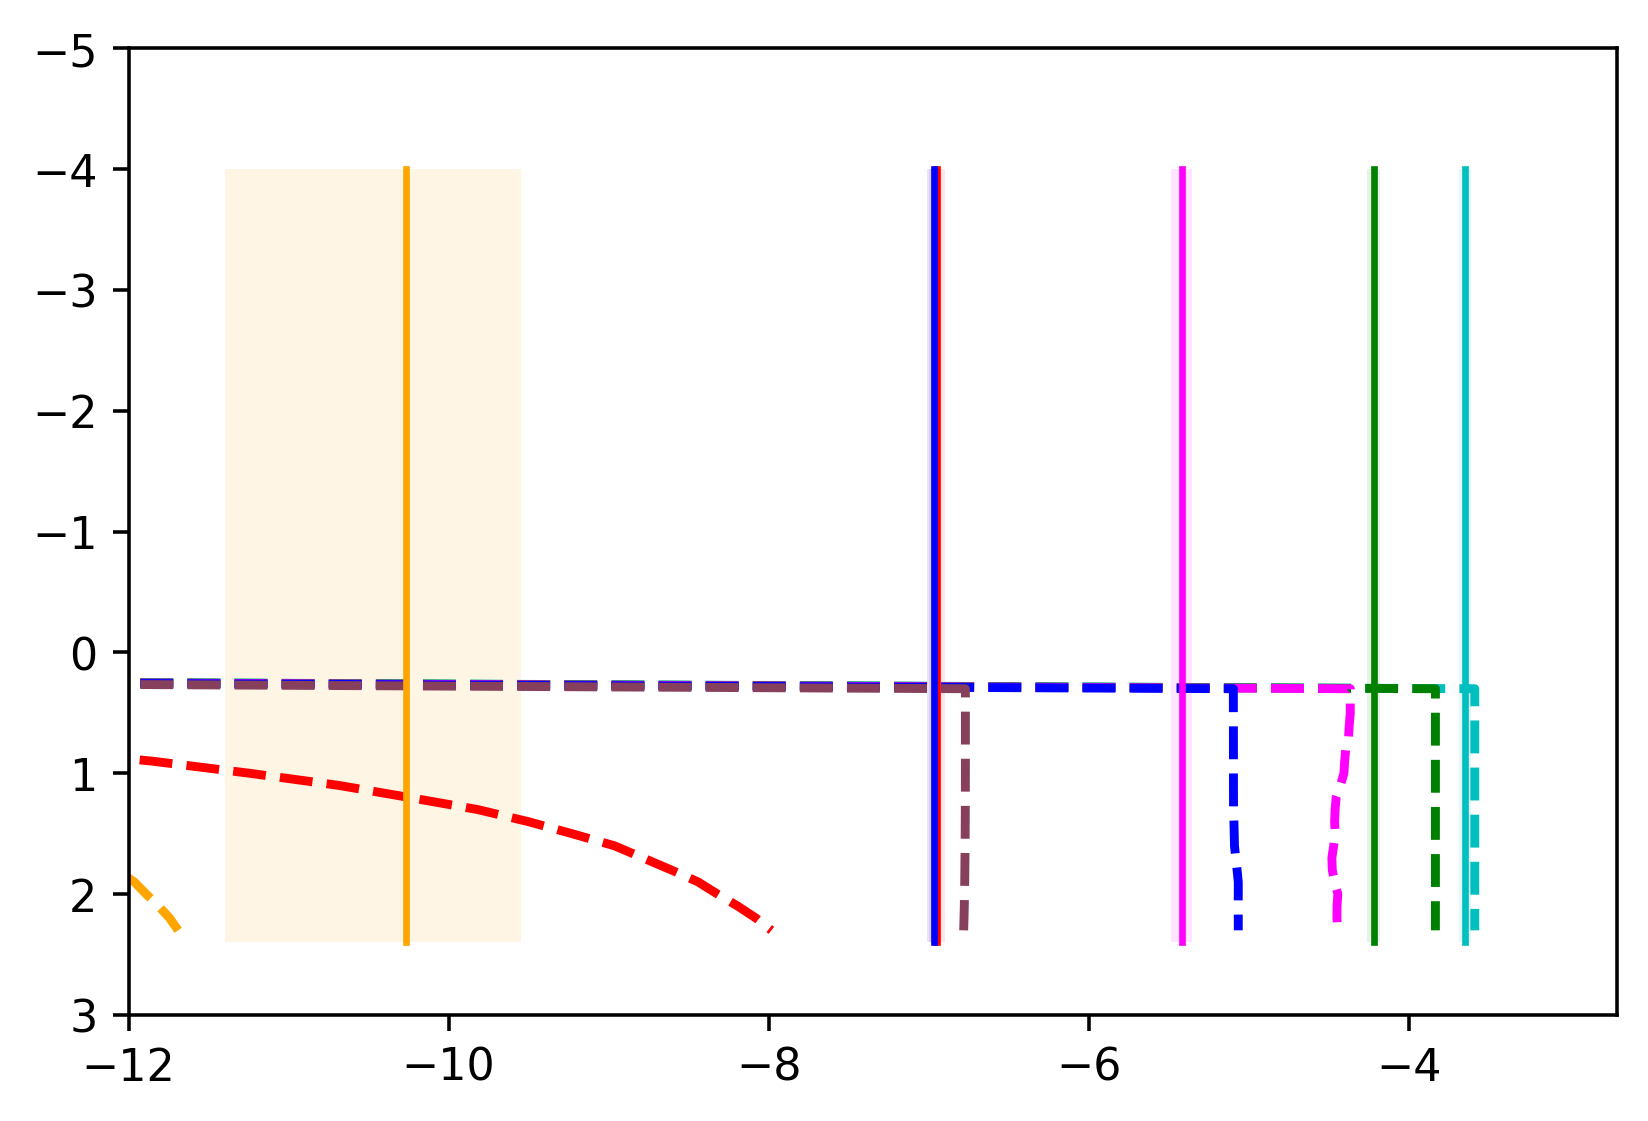

In [31]:
from matplotlib.lines import Line2D
#All on same plot
# ------- Create the Plot ------
fig6=plt.figure(dpi=320)
# ax = fig.add_subplot(1,1,1)
plt.axis([-12, -2.7, 3.0, -5.0])

# Add the gases to the plots. The gases numbers come from Channon's table (intab) in the following order:
# (0) e-, (1) H2, (2) H, (3) H+, (4) H-, (5) H2-, (6) H2+, (7) H3+, (8) He, (9) H2O, (10) CH4, (11) CO, (12) NH3,
# (13) N2, (14) PH3, (15) H2S, (16) TiO, (17) VO, (18) Fe, (19) FeH, (20) CrH, (21) Na, (22) K, (23) Rb, (24) Cs,
# (25) CO2, (26) HCN, (27) C2H2, (28) C2H4, (29) C2H6, (30) SiO, (31) MgH, (32) OCS, (33) Li, (34) LiOH,  (35) LiH,
# (36) LiCl, (37) graphite

#--- Add Model Gas values from Solar grid for now-----
h2o_mod, = plt.plot(ab[:, 9], logP, '--', color='#00BFBF', linewidth=2, label='H$_\mathrm{2}$O Model')
ch4_mod, = plt.plot(ab[:, 10], logP, '--', color='green', linewidth=2, label='CH$_\mathrm{4}$ Model')
co_mod, = plt.plot(ab[:, 11], logP, '--', color='red', linewidth=2, label='CH$_\mathrm{4}$ Model')
co2_mod, = plt.plot(ab[:, 25], logP, '--', color='orange', linewidth=2, label='CH$_\mathrm{4}$ Model')
nh3_mod, = plt.plot(ab[:, 12], logP, '--', color='magenta', linewidth=2, label='NH$_\mathrm{3}$ Model')
h2s_mod, = plt.plot(ab[:, 15], logP, '--', color='blue', linewidth=2, label='H$_\mathrm{2}S$ Model')
ph3_mod, = plt.plot(ab[:, 14], logP, '--', color='#87405C', linewidth=2, label='PH$_\mathrm{3}$ Model')
# alks = np.log10((10. ** ab[:, 22]) + (10. ** ab[:, 21]))
# NaK_mod, = plt.plot(alks, logP, '--', color='#87405C', linewidth=2, label='Na + K Model')

#----Add Retreived Values----
h2O, = plt.plot([vmr[0, 1], vmr[0, 1]], [2.4, -4.0], '-', color='#00BFBF', label='H$_\mathrm{2}$O')
plt.fill_betweenx([2.4, -4.0], [vmr[0, 0], vmr[0, 0]], [vmr[0, 2], vmr[0, 2]], facecolor='#00BFBF', alpha=0.1, linewidth=0)#, label="H2O")

ch4, = plt.plot([vmr[1, 1], vmr[1, 1]], [2.4, -4.0], '-', color='green', label='CH4')
plt.fill_betweenx([2.4, -4.0], [vmr[1, 0], vmr[1, 0]], [vmr[1, 2], vmr[1, 2]], facecolor='green', alpha=0.1,
                  linewidth=0)

co, = plt.plot([vmr[2, 1], vmr[2, 1]], [2.4, -4.0], '-', color='red', label='CH4')
plt.fill_betweenx([2.4, -4.0], [vmr[2, 0], vmr[2, 0]], [vmr[2, 2], vmr[2, 2]], facecolor='red', alpha=0.1,
                  linewidth=0)

co2, = plt.plot([vmr[3, 1], vmr[3, 1]], [2.4, -4.0], '-', color='orange', label='CH4')
plt.fill_betweenx([2.4, -4.0], [vmr[3, 0], vmr[3, 0]], [vmr[3, 2], vmr[3, 2]], facecolor='orange', alpha=0.1,
                  linewidth=0)


nh3, = plt.plot([vmr[4, 1], vmr[4, 1]], [2.4, -4.0], '-', color='magenta', label='CH4')
plt.fill_betweenx([2.4, -4.0], [vmr[4, 0], vmr[4, 0]], [vmr[4, 2], vmr[4, 2]], facecolor='magenta', alpha=0.1,
                  linewidth=0)
# Na_K, = plt.plot([vmr[3, 1], vmr[3, 1]], [2.4, -4.0], '-', color='#87405C', label='Na+K')
# plt.fill_betweenx([2.4, -4.0], [vmr[3, 0], vmr[3, 0]], [vmr[3, 2], vmr[3, 2]], facecolor='#87405C', alpha=0.1,
#                   linewidth=0)
# with H2S
h2s, = plt.plot([vmr[5, 1], vmr[5, 1]], [2.4, -4.0], '-', color='blue', label='CH4')
plt.fill_betweenx([2.4, -4.0], [vmr[5, 0], vmr[5, 0]], [vmr[5, 2], vmr[5, 2]], facecolor='blue', alpha=0.1,
                  linewidth=0)

nh3, = plt.plot([vmr[6, 1], vmr[6, 1]], [2.4, -4.0], '-', color='#87405C', label='CH4')
plt.fill_betweenx([2.4, -4.0], [vmr[6, 0], vmr[6, 0]], [vmr[6, 2], vmr[6, 2]], facecolor='#87405C', alpha=0.1,
                  linewidth=0)

# Na_K, = plt.plot([vmr[4, 1], vmr[4, 1]], [2.4, -4.0], '-', color='#87405C', label='Na+K')
# plt.fill_betweenx([2.4, -4.0], [vmr[4, 0], vmr[4, 0]], [vmr[4, 2], vmr[4, 2]], facecolor='#87405C', alpha=0.1,
#                   linewidth=0)

#Add photosphere range
plt.fill_between([-12.0,12.0],np.log10(70),np.log10(0.1),facecolor='grey',alpha=0.1) # block for the photosphere
plt.annotate('photosphere', xy=(-8.4, 0.4), color='k', fontsize=10)

# Add legend and labels that are shared over all the subplots
# create lines for custom legend
custom_lines = [Line2D([0], [0], color='k', ls='-'),
                Line2D([0], [0], color='k', ls='dashed')]
legend=plt.legend(custom_lines, ['Retrieved Abundance', '-0.5 Metallicity Model Abundance'], loc='lower left',
                  bbox_to_anchor= (0, 1.01), ncol=2, borderaxespad=0, fontsize=9)

#Add labels for Gases
plt.annotate('H$_\mathrm{2}$O', xy=(-8.4, -4), color='#00BFBF', fontsize=15) 
plt.annotate('CH$_\mathrm{4}$', xy=(-8.4, -3.5), color='green', fontsize=15)
plt.annotate('CO', xy=(-8.4, -3), color='red', fontsize=15)
plt.annotate('CO$_\mathrm{2}$', xy=(-8.4, -2.5), color='orange', fontsize=15)
plt.annotate('NH$_\mathrm{3}$', xy=(-8.4, -2), color='magenta', fontsize=15)
plt.annotate('H$_\mathrm{2}S$', xy=(-8.4, -1.5), color='blue', fontsize=15)
plt.annotate('PH$_\mathrm{3}$', xy=(-8.4, -1), color='#87405C', fontsize=15)
# plt.annotate('Na+K', xy=(-8.4, -2.5), color='#87405C', fontsize=15)
# txt = fig5.text(0.5, 0.02, '$\log\,f_{gas}$', ha='center', fontsize=20)
plt.ylabel('$\log\,P$  (bars)',fontsize=20)
plt.xlabel('$\log\,f_{gas}$',fontsize=20)
plt.savefig(figure_path + runname +"_ext"+ext_num+ '_abundances_newgrid.pdf', format='pdf', dpi=320, bbox_inches='tight')

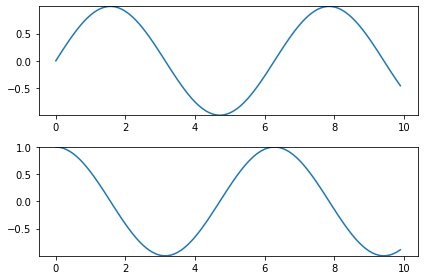

In [65]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data
x = np.arange(0, 10, 0.1)
y1 = np.sin(x)
y2 = np.cos(x)

# Create subplots
fig, axs = plt.subplots(2, 1)

# Plot data on each subplot
axs[0].plot(x, y1)
axs[1].plot(x, y2)

# Automatically set limits
axs[0].set_ylim(np.min(y1), np.max(y1))
axs[1].set_ylim(np.min(y2), np.max(y2))

# Adjust subplot layout
plt.tight_layout()
plt.show()